# PM-PR-0015 - Bank GoodCredit Credit Risk Prediction

**Client:** Bank GoodCredit  
**Category:** Banking - Risk Analytics  
**Project Reference:** PM-PR-0015  
**Candidate:** Ravi Kumar/Jackson J/Bindhu

## Business Problem

Bank GoodCredit wants to predict the credit risk of current credit card customers.  
The business objective is to identify customers who are likely to become risky in the future, especially customers who may fall into the 30+ days-past-due bucket.

## Target Variable

The target variable is:

`Bad_label`

After column cleaning, this becomes:

`bad_label`

Meaning:

- `0` = Customer has good credit history
- `1` = Customer has bad credit history / 30+ DPD risk

## Project Objectives

1. Load data from the SQL database.
2. Perform detailed data quality checks and exploratory analysis.
3. Create a customer-level feature matrix from account, enquiry, and demographic data.
4. Build and compare multiple machine learning models.
5. Evaluate models using ROC-AUC, Gini, and rank ordering.
6. Provide business recommendations and challenges faced.

## Why This Project Matters

In banking, credit risk prediction helps reduce default losses, improve credit approval strategy, and monitor existing customers more effectively.

## 1. Import Required Libraries

This section imports all required Python libraries.

### Simple Explanation

- `pandas` and `numpy` are used for data handling.
- `matplotlib` and `seaborn` are used for charts.
- `sqlalchemy` is used to connect Python with MySQL.
- `sklearn` is used for preprocessing, model building, hyperparameter tuning, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import getpass

from urllib.parse import quote_plus
from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Database Connection

The project data is stored in a MySQL database.

### Important Note

The password contains special characters.  
So, the password is encoded safely using `quote_plus()` before creating the SQL connection string.

### Simple Explanation

This avoids connection errors when the password contains special characters such as `@`, `!`, `$`, or `&`.

In [2]:
host = "18.136.157.135"
port = 3306
database = "project_banking"
username = "dm_team1"

password = getpass.getpass("Enter MySQL password: ")

encoded_password = quote_plus(password)

connection_string = f"mysql+pymysql://{username}:{encoded_password}@{host}:{port}/{database}"

engine = create_engine(connection_string)

print("Database connection object created successfully.")

Database connection object created successfully.


## 3. Load SQL Tables

The project PDF mentions three SQL tables:

1. `Cust_Account`
2. `Cust_Enquiry`
3. `Cust_Demographics`

### Simple Explanation

Each table contains a different type of customer information.  
We will later merge all three tables into one customer-level modeling dataset.

In [3]:
cust_account = pd.read_sql("SELECT * FROM Cust_Account", engine)
cust_enquiry = pd.read_sql("SELECT * FROM Cust_Enquiry", engine)
cust_demo = pd.read_sql("SELECT * FROM Cust_Demographics", engine)

print("Customer Account Shape:", cust_account.shape)
print("Customer Enquiry Shape:", cust_enquiry.shape)
print("Customer Demographics Shape:", cust_demo.shape)

display(cust_account.head())
display(cust_enquiry.head())
display(cust_demo.head())

Customer Account Shape: (186329, 21)
Customer Enquiry Shape: (413188, 6)
Customer Demographics Shape: (23896, 83)


,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,cur_balance_amt,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
0,10-Nov-15,12265,20-Oct-15,6,1,09-Jun-13,30-Jun-14,05-Jul-14,30-Sep-15,20900,0,,"""""""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXS...",,01-Sep-15,01-Jul-14,,,,,
1,10-Nov-15,12265,20-Oct-15,10,1,25-May-12,06-Sep-15,,03-Oct-15,16201,10390,,"""""""0000000000000000000000000000000000000000000...","""""""000000000000000000000000000XXX0000000000000...",01-Oct-15,01-Nov-12,14000,1400,,3,5603
2,10-Nov-15,12265,20-Oct-15,10,1,22-Mar-12,31-Aug-15,,30-Sep-15,41028,34420,,"""""""0000000000000000000000000000000000000000000...","""""""0000000000000000000000000000000000000000000...",01-Sep-15,01-Oct-12,,,,,
3,20-Jul-15,15606,09-Jul-15,10,1,13-Jan-06,,26-Jul-07,31-Jan-09,93473,0,,"""""""1200900600600600300000000000000000000000000...",,01-Jul-07,01-Feb-06,,,,,
4,20-Jul-15,15606,09-Jul-15,6,1,18-Jan-15,05-May-15,,31-May-15,20250,13500,,"""""""000000000000000""""""",,01-May-15,01-Jan-15,,,,,


,dt_opened,customer_no,upload_dt,enquiry_dt,enq_purpose,enq_amt
0,18-Apr-15,1,21-Apr-15,19-Dec-14,2,3500000
1,18-Apr-15,1,21-Apr-15,05-Mar-14,5,500000
2,18-Apr-15,1,21-Apr-15,05-Mar-14,0,50000
3,18-Apr-15,1,21-Apr-15,22-Feb-14,10,50000
4,18-Apr-15,1,21-Apr-15,11-Jun-13,10,1000


,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,Bad_label
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650,2,Card Setup,14,500000,,,,Y,IS1,,0,159,4284,4284,,1,ADFPNXXXXX,03-Sep-65,98332XXXXX,N,@REDIFFMAIL.COM,1,2,,Mumbai / Navi Mumbai / Thane,400610,1965,0,Self,Y,2,90000,,,,0,0,0,0,Mumbai,400059,@CODOGNOTTO.NET,PAN Card,ADFPNXXXXX,The Ratnakar Bank Ltd.,,Y,State Bank of India,0,01-Jun-13,17-Jun-16,1,21,,Y,Y,N,,Y,1965-0,21,15,400610,0,2,90000,Nov-00,21,R,,,0000-00-00,0,98332XXXXX,1,N,0
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760,1,Card Setup,14,1200000,,,,Y,IS1,,0,91,B001,4077,,1,AJWPRXXXXX,14-Jul-62,99455XXXXX,N,@GMAIL.COM,1,2,,Bengaluru,560042,1969,0,Self,Y,2,1,,,,0,0,0,0,Bangalore,560042,,PAN Card,AJWPRXXXXX,The Ratnakar Bank Ltd.,,N,,0,,17-Jun-16,1,17,,Y,Y,N,,Y,1969-0,17,12,560042,0,2,1,Nov-00,17,R,,,0000-00-00,0,99455XXXXX,1,N,0
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774,1,Card Setup,14,700000,,,,Y,IS1,,0,91,B001,4077,,2,AFAPNXXXXX,10-Apr-66,98456XXXXX,N,@SHOBANARAYAN.COM,1,0,,Bengaluru,560042,1966,0,Self,Y,2,1,,,,0,0,0,0,Bangalore,560042,,PAN Card,AFAPNXXXXX,,,N,,0,,17-Jun-16,3,17,,N,Y,N,,Y,1966-0,17,12,560042,0,2,1,Nov-00,17,R,,,0000-00-00,0,98456XXXXX,1,N,0
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770,1,Card Setup,14,500000,,,,Y,IS1,,0,157,5107,5107,,1,AAAPDXXXXX,16-Apr-64,98220XXXXX,N,@VSNL.COM,1,3,,Pune,411001,1988,0,Self,Y,2,100000,,,,0,0,0,0,Pune,411026,@ALBAJ.COM,PAN Card,AAAPDXXXXX,The Ratnakar Bank Ltd.,,Y,HDFC Bank,0,,17-Jun-16,1,21,,Y,Y,N,,Y,1988-0,21,16,411001,0,2,100000,Nov-00,21,R,,,6/15/65,1,98220XXXXX,1,N,0
4,06-May-15,5,30-Apr-15,Insignia,,,3,Card Setup,14,500000,,,,Y,IS1,,0,100,D016,4564,,1,ABEPSXXXXX,03-Jan-54,98111XXXXX,N,@REDIFFMAIL.COM,1,3,,Gurgaon,122009,1995,0,Self,Y,2,300000,,,,0,0,0,0,Gurgaon,122009,,PAN Card,ABEPSXXXXX,The Ratnakar Bank Ltd.,,N,,0,,17-Jun-16,1,13,,Y,Y,N,,Y,1995-0,13,3,122009,0,2,300000,Nov-00,13,R,,,0000-00-00,0,98111XXXXX,1,N,0


## 4. Review Table Structure

Before cleaning and modeling, we review each table structure.

### Simple Explanation

This helps us understand:
- Number of rows and columns
- Column names
- Data types
- Whether values are stored as text or numbers

In [4]:
print("Customer Account Info:")
cust_account.info()

print()
print("Customer Enquiry Info:")
cust_enquiry.info()

print()
print("Customer Demographics Info:")
cust_demo.info()

Customer Account Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186329 entries, 0 to 186328
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   dt_opened            186329 non-null  object
 1   customer_no          186329 non-null  object
 2   upload_dt            186329 non-null  object
 3   acct_type            186329 non-null  object
 4   owner_indic          186329 non-null  object
 5   opened_dt            186329 non-null  object
 6   last_paymt_dt        186329 non-null  object
 7   closed_dt            186329 non-null  object
 8   reporting_dt         186329 non-null  object
 9   high_credit_amt      186329 non-null  object
 10  cur_balance_amt      186329 non-null  object
 11  amt_past_due         186329 non-null  object
 12  paymenthistory1      186329 non-null  object
 13  paymenthistory2      186329 non-null  object
 14  paymt_str_dt         186329 non-null  object
 15  paymt_end_d

## 5. Standardize Column Names

Column names are standardized to make coding easier.

### Simple Explanation

For example:

`Bad_label` becomes `bad_label`

This avoids errors caused by uppercase/lowercase differences.

In [5]:
def clean_column_names(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
    return df

cust_account = clean_column_names(cust_account)
cust_enquiry = clean_column_names(cust_enquiry)
cust_demo = clean_column_names(cust_demo)

print("Account Columns:")
print(cust_account.columns.tolist())

print()
print("Enquiry Columns:")
print(cust_enquiry.columns.tolist())

print()
print("Demographics Columns:")
print(cust_demo.columns.tolist())

Account Columns:
['dt_opened', 'customer_no', 'upload_dt', 'acct_type', 'owner_indic', 'opened_dt', 'last_paymt_dt', 'closed_dt', 'reporting_dt', 'high_credit_amt', 'cur_balance_amt', 'amt_past_due', 'paymenthistory1', 'paymenthistory2', 'paymt_str_dt', 'paymt_end_dt', 'creditlimit', 'cashlimit', 'rateofinterest', 'paymentfrequency', 'actualpaymentamount']

Enquiry Columns:
['dt_opened', 'customer_no', 'upload_dt', 'enquiry_dt', 'enq_purpose', 'enq_amt']

Demographics Columns:
['dt_opened', 'customer_no', 'entry_time', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature

## 6. Basic Data Cleaning Helpers

The SQL data contains many columns as text/object type even when they represent numeric amounts.  
So, helper functions are created to clean numeric and date columns safely.

### Simple Explanation

This step prevents errors such as:

`TypeError: agg function failed [how->mean,dtype->object]`

because we convert numeric-looking text values into real numeric values before aggregation.

In [6]:
def replace_blank_with_nan(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .replace(["", "nan", "NaN", "None", "NULL", "null"], np.nan)
            )
    return df

def convert_to_numeric_safe(df, columns):
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.strip()
                .replace(["", "nan", "NaN", "None", "NULL", "null"], np.nan)
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def convert_date_columns(df, date_cols):
    df = df.copy()
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

cust_account = replace_blank_with_nan(cust_account)
cust_enquiry = replace_blank_with_nan(cust_enquiry)
cust_demo = replace_blank_with_nan(cust_demo)

print("Blank values replaced with NaN successfully.")

Blank values replaced with NaN successfully.


## 7. Convert Important Data Types

The raw SQL output stores many numeric fields as object/text.  
We convert required numeric and date columns before EDA and feature engineering.

### Simple Explanation

Machine learning models and aggregation functions require proper numeric values.

In [7]:
account_numeric_cols = [
    "high_credit_amt",
    "cur_balance_amt",
    "amt_past_due",
    "creditlimit",
    "cashlimit",
    "rateofinterest",
    "actualpaymentamount"
]

enquiry_numeric_cols = [
    "enq_amt"
]

# Demographic features that look numeric will also be converted later using a separate method
cust_account = convert_to_numeric_safe(cust_account, account_numeric_cols)
cust_enquiry = convert_to_numeric_safe(cust_enquiry, enquiry_numeric_cols)

account_date_cols = [
    "dt_opened", "upload_dt", "opened_dt", "last_paymt_dt",
    "closed_dt", "reporting_dt", "paymt_str_dt", "paymt_end_dt"
]

enquiry_date_cols = [
    "dt_opened", "upload_dt", "enquiry_dt"
]

demo_date_cols = [
    "dt_opened", "entry_time"
]

cust_account = convert_date_columns(cust_account, account_date_cols)
cust_enquiry = convert_date_columns(cust_enquiry, enquiry_date_cols)
cust_demo = convert_date_columns(cust_demo, demo_date_cols)

# Target column conversion
if "bad_label" in cust_demo.columns:
    cust_demo["bad_label"] = pd.to_numeric(cust_demo["bad_label"], errors="coerce")

print("Data type conversion completed successfully.")

Data type conversion completed successfully.


## 8. Data Quality Checks

We check missing values and duplicate rows in each table.

### Simple Explanation

Data quality checks are important because poor data quality can reduce model reliability.

In [8]:
tables = {
    "Customer Account": cust_account,
    "Customer Enquiry": cust_enquiry,
    "Customer Demographics": cust_demo
}

for table_name, table_df in tables.items():
    print("=" * 80)
    print(table_name)
    print("Shape:", table_df.shape)
    print("Duplicate Rows:", table_df.duplicated().sum())
    print("Total Missing Values:", table_df.isnull().sum().sum())
    print("Top Missing Columns:")
    display(table_df.isnull().sum().sort_values(ascending=False).head(10))

Customer Account
Shape: (186329, 21)
Duplicate Rows: 2401
Total Missing Values: 1154913
Top Missing Columns:


amt_past_due           185453
rateofinterest         161506
cashlimit              151047
actualpaymentamount    145276
creditlimit            137477
paymentfrequency       122436
closed_dt              109075
paymenthistory2        107824
last_paymt_dt           25487
high_credit_amt          8875
dtype: int64

Customer Enquiry
Shape: (413188, 6)
Duplicate Rows: 13827
Total Missing Values: 440
Top Missing Columns:


enquiry_dt     110
upload_dt      110
enq_purpose    110
enq_amt        110
customer_no      0
dt_opened        0
dtype: int64

Customer Demographics
Shape: (23896, 83)
Duplicate Rows: 0
Total Missing Values: 333644
Top Missing Columns:


feature_61    23887
feature_74    23879
feature_18    23878
feature_10    23845
feature_49    23792
feature_17    22869
feature_8     22635
feature_9     22635
feature_57    21503
feature_73    20951
dtype: int64

## 9. Target Variable Analysis

The target column is `bad_label`.

### Simple Explanation

This is a binary classification problem:

- `0` = Good customer
- `1` = Bad customer

Since bad customers are usually fewer in credit risk datasets, the data is expected to be imbalanced.

,Count,Percentage
bad_label,,
0,22892,95.8
1,1004,4.2


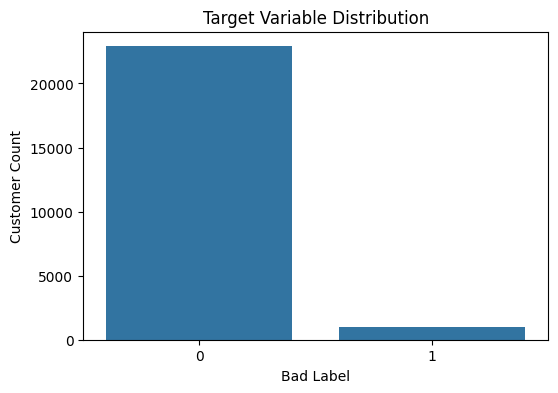

Overall Bad Rate: 4.2 %


In [9]:
if "bad_label" not in cust_demo.columns:
    raise ValueError("Target column 'bad_label' not found in Customer Demographics table.")

cust_demo = cust_demo.dropna(subset=["bad_label"])
cust_demo["bad_label"] = cust_demo["bad_label"].astype(int)

target_counts = cust_demo["bad_label"].value_counts().sort_index()
target_percentage = cust_demo["bad_label"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentage.round(2)
})

display(target_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=cust_demo, x="bad_label")
plt.title("Target Variable Distribution")
plt.xlabel("Bad Label")
plt.ylabel("Customer Count")
plt.show()

bad_rate = cust_demo["bad_label"].mean() * 100
print("Overall Bad Rate:", round(bad_rate, 2), "%")

## 10. Demographic Feature Type Conversion

Many demographic variables are stored as text.  
Some of them are actually numeric-like, while others are categorical.

### Simple Explanation

We try converting feature columns to numeric only when most values look numeric.  
This avoids forcing genuine categorical columns into numbers.

In [10]:
demo_feature_cols = [col for col in cust_demo.columns if col.startswith("feature_")]

for col in demo_feature_cols:
    converted = pd.to_numeric(cust_demo[col], errors="coerce")
    non_missing_original = cust_demo[col].notna().sum()
    non_missing_converted = converted.notna().sum()

    if non_missing_original > 0:
        numeric_ratio = non_missing_converted / non_missing_original
    else:
        numeric_ratio = 0

    # Convert only when at least 80% of non-missing values are numeric
    if numeric_ratio >= 0.80:
        cust_demo[col] = converted

demo_numeric_cols = cust_demo.select_dtypes(include=[np.number]).columns.tolist()
demo_numeric_cols = [col for col in demo_numeric_cols if col not in ["bad_label", "customer_no"]]

demo_categorical_cols = cust_demo.select_dtypes(exclude=[np.number, "datetime64[ns]"]).columns.tolist()
demo_categorical_cols = [col for col in demo_categorical_cols if col not in ["customer_no"]]

print("Number of numerical demographic features:", len(demo_numeric_cols))
print("Number of categorical demographic features:", len(demo_categorical_cols))

Number of numerical demographic features: 35
Number of categorical demographic features: 44


## 10A. Demographic Feature Summary Table

The demographics table contains anonymized fields such as `feature_1`, `feature_2`, etc.  
Since the actual business names are not available, this summary table helps the evaluator understand the structure of each anonymized feature.

### What This Table Shows

- Feature name
- Data type after conversion
- Missing value count
- Missing value percentage
- Unique value count
- Feature category: Numeric or Categorical

### Business Interpretation

Even though the original meaning of each demographic feature is hidden, the feature summary helps us understand whether a variable behaves like a continuous numerical field, a binary/categorical flag, or a high-cardinality identifier-like field.

,Feature,Data Type,Feature Category,Missing Count,Missing %,Unique Values
0,feature_1,object,Categorical,15,0.06,7
1,feature_2,object,Categorical,2836,11.87,281
2,feature_3,float64,Numeric,2836,11.87,262
3,feature_4,float64,Numeric,15,0.06,3
4,feature_5,object,Categorical,15,0.06,1
5,feature_6,float64,Numeric,15,0.06,1
6,feature_7,float64,Numeric,15,0.06,484
7,feature_8,object,Categorical,22635,94.72,19
8,feature_9,object,Categorical,22635,94.72,19
9,feature_10,float64,Numeric,23846,99.79,6


Feature Summary Shape: (79, 6)


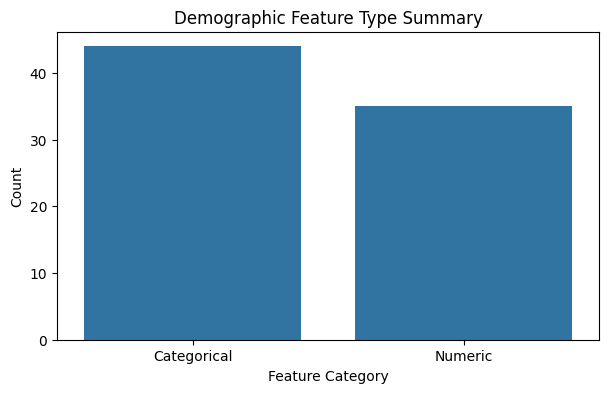

In [11]:
feature_summary = []

for col in demo_feature_cols:
    if col in cust_demo.columns:
        missing_count = cust_demo[col].isnull().sum()
        missing_pct = (missing_count / len(cust_demo)) * 100
        unique_count = cust_demo[col].nunique(dropna=True)
        dtype_value = str(cust_demo[col].dtype)

        if pd.api.types.is_numeric_dtype(cust_demo[col]):
            feature_category = "Numeric"
        else:
            feature_category = "Categorical"

        feature_summary.append({
            "Feature": col,
            "Data Type": dtype_value,
            "Feature Category": feature_category,
            "Missing Count": missing_count,
            "Missing %": round(missing_pct, 2),
            "Unique Values": unique_count
        })

feature_summary_df = pd.DataFrame(feature_summary)

display(feature_summary_df.head(30))

print("Feature Summary Shape:", feature_summary_df.shape)

plt.figure(figsize=(7, 4))
sns.countplot(data=feature_summary_df, x="Feature Category")
plt.title("Demographic Feature Type Summary")
plt.xlabel("Feature Category")
plt.ylabel("Count")
plt.show()

## 11. EDA - Demographic Features

We visualize sample demographic numeric features.

### Simple Explanation

Because the feature names are anonymized, we focus on distribution patterns instead of business names.

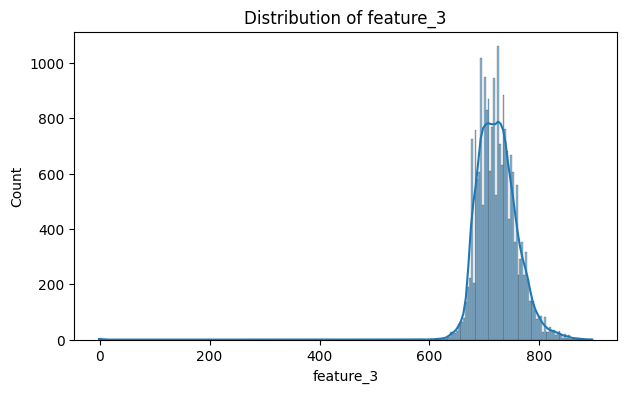

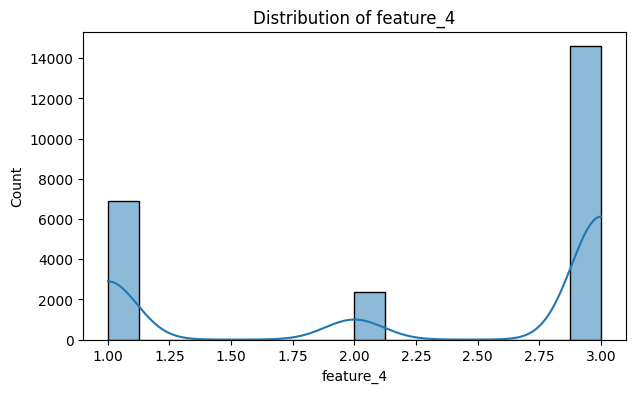

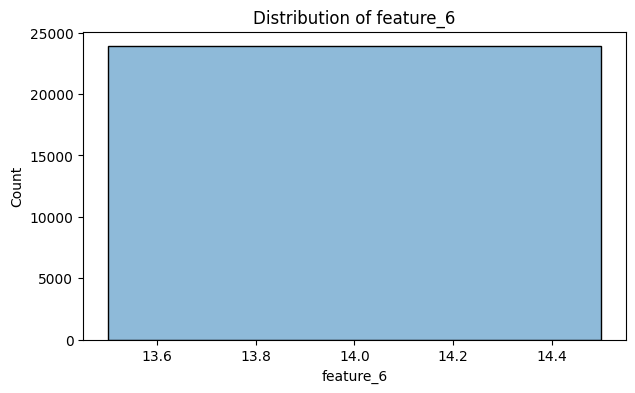

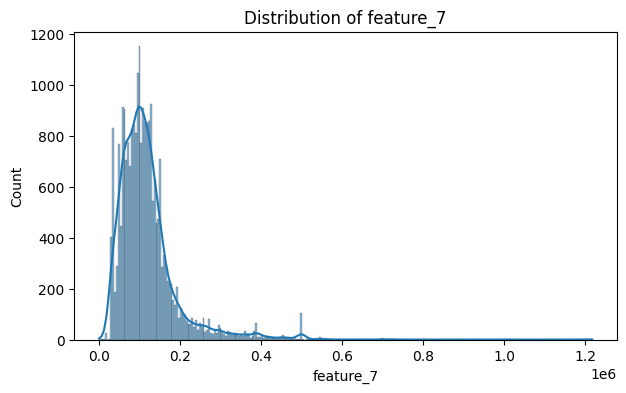

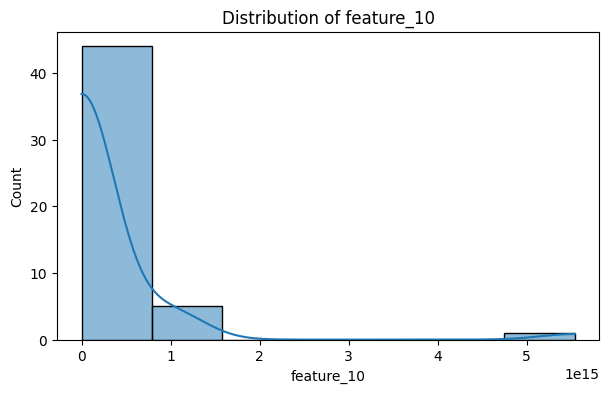

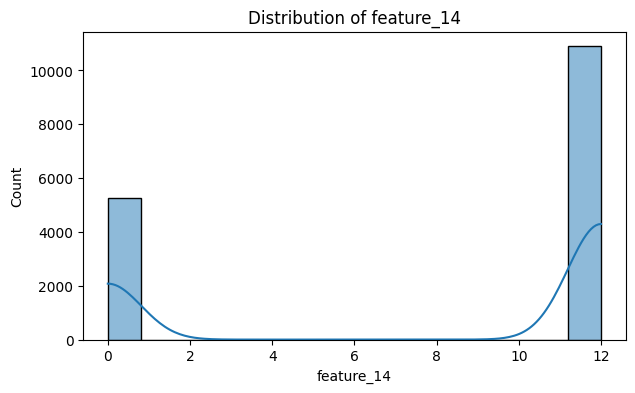

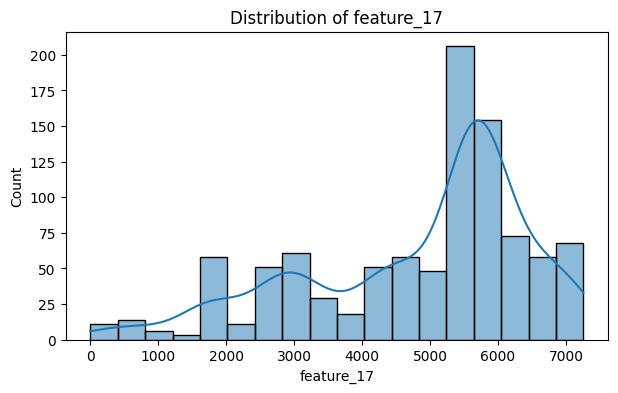

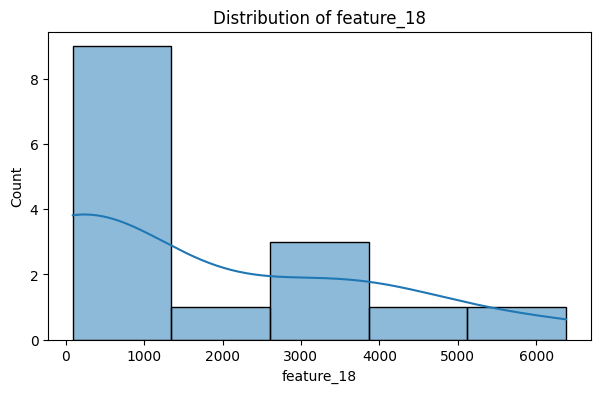

In [12]:
sample_demo_cols = demo_numeric_cols[:8]

if len(sample_demo_cols) == 0:
    print("No numeric demographic features available after conversion.")
else:
    for col in sample_demo_cols:
        plt.figure(figsize=(7, 4))
        sns.histplot(cust_demo[col].dropna(), kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

## 12. EDA - Demographic Relationship with Target

We compare average feature values between good and bad customers.

### Simple Explanation

Features showing meaningful differences between good and bad customers may help the model predict credit risk.

In [13]:
if len(demo_numeric_cols) > 0:
    target_feature_summary = cust_demo.groupby("bad_label")[demo_numeric_cols[:15]].mean().T

    if 0 in target_feature_summary.columns and 1 in target_feature_summary.columns:
        target_feature_summary.columns = ["Good_Customers", "Bad_Customers"]
        target_feature_summary["Difference"] = (
            target_feature_summary["Bad_Customers"] - target_feature_summary["Good_Customers"]
        )
        display(target_feature_summary.sort_values(by="Difference", ascending=False).head(15))
    else:
        display(target_feature_summary)
else:
    print("No numeric demographic features available for target comparison.")

,Good_Customers,Bad_Customers,Difference
feature_17,4.825246e+03,5067.225806,241.979766
feature_30,2.001168e+03,2001.554337,0.386578
feature_4,2.318384e+00,2.394816,0.076431
feature_25,1.231970e+00,1.278166,0.046196
feature_34,1.237390e+00,1.272183,0.034794
feature_19,1.049174e+00,1.054835,0.005662
feature_6,1.400000e+01,14.000000,0.000000
feature_31,6.556080e-01,0.577268,-0.078340
feature_14,8.091213e+00,7.966387,-0.124826
feature_26,7.313576e-01,0.595214,-0.136143


## 13. EDA - Account Table

We explore important account-level financial variables.

### Simple Explanation

Account variables such as current balance, credit limit, overdue amount, and high credit amount are directly relevant to credit risk.

Important account columns found:
['high_credit_amt', 'cur_balance_amt', 'amt_past_due', 'creditlimit', 'cashlimit', 'rateofinterest', 'actualpaymentamount']


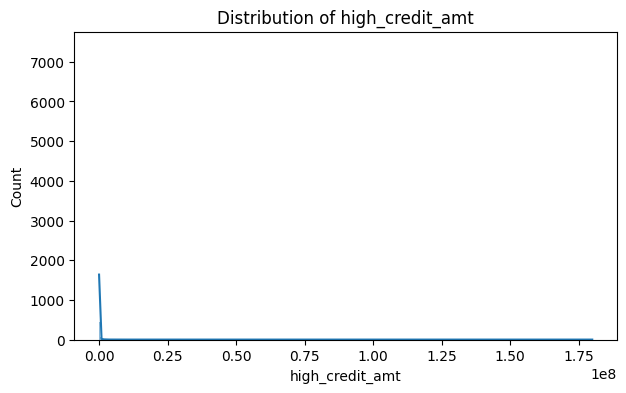

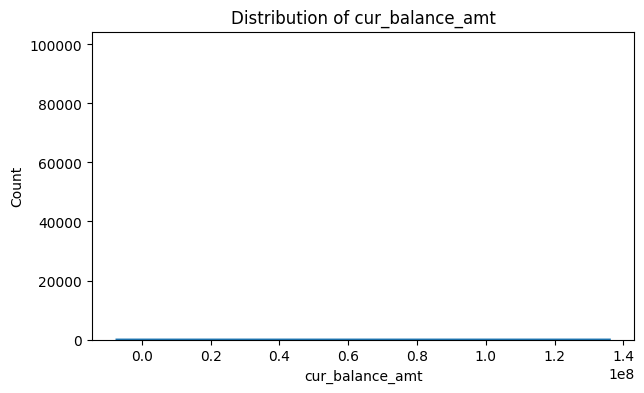

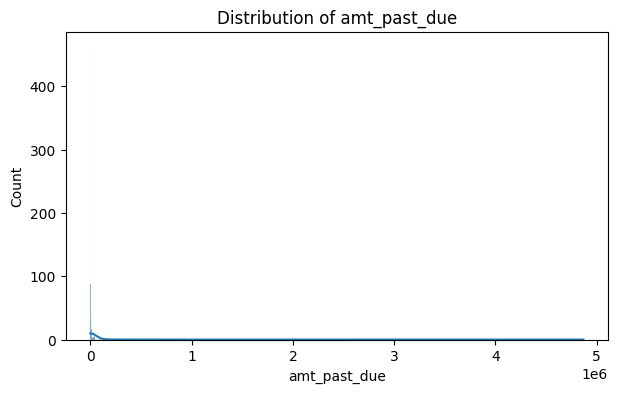

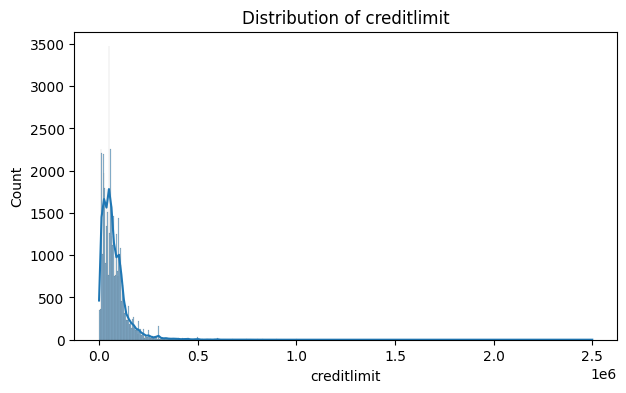

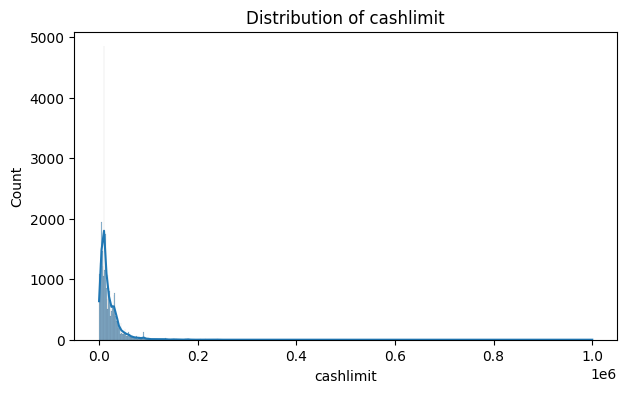

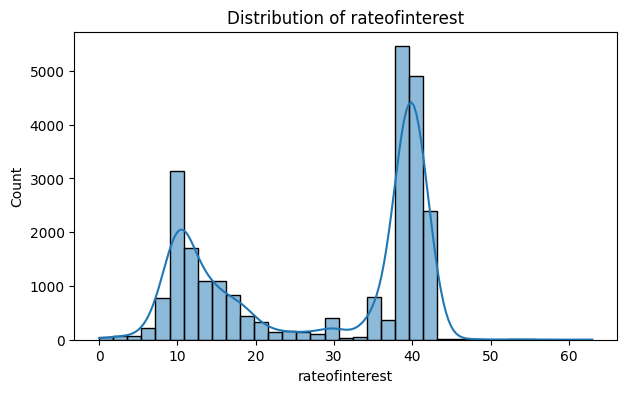

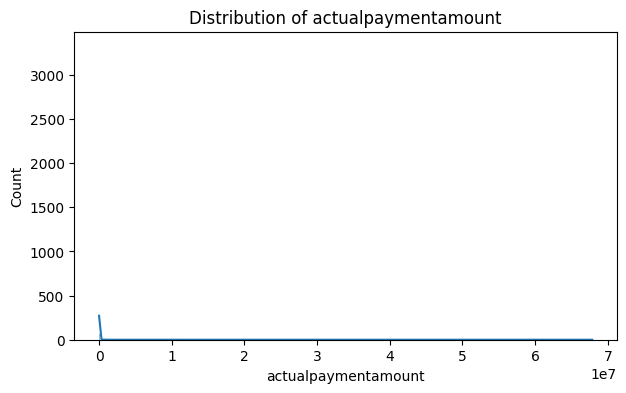

In [14]:
important_account_cols = [
    col for col in account_numeric_cols if col in cust_account.columns
]

print("Important account columns found:")
print(important_account_cols)

for col in important_account_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(cust_account[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 14. EDA - Enquiry Table

We explore enquiry amount and enquiry purpose.

### Simple Explanation

A high number of enquiries or high enquiry amount can indicate credit-seeking behavior.

Enquiry Columns:
['dt_opened', 'customer_no', 'upload_dt', 'enquiry_dt', 'enq_purpose', 'enq_amt']


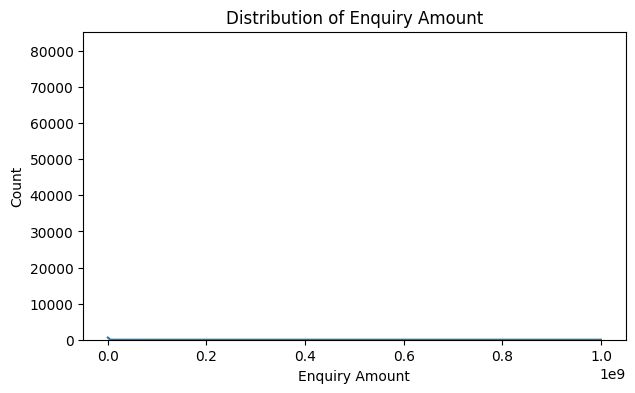

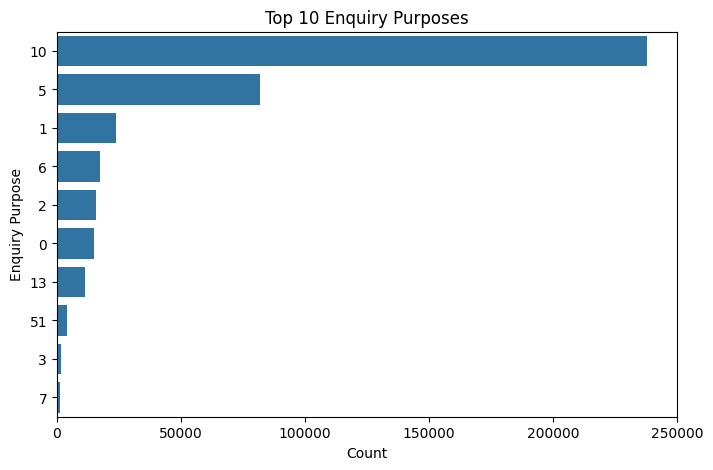

In [15]:
print("Enquiry Columns:")
print(cust_enquiry.columns.tolist())

if "enq_amt" in cust_enquiry.columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(cust_enquiry["enq_amt"].dropna(), kde=True)
    plt.title("Distribution of Enquiry Amount")
    plt.xlabel("Enquiry Amount")
    plt.ylabel("Count")
    plt.show()

if "enq_purpose" in cust_enquiry.columns:
    top_purpose = cust_enquiry["enq_purpose"].value_counts().head(10)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=top_purpose.values, y=top_purpose.index.astype(str))
    plt.title("Top 10 Enquiry Purposes")
    plt.xlabel("Count")
    plt.ylabel("Enquiry Purpose")
    plt.show()

## 15. Feature Engineering - Account Features

We aggregate account data at customer level.

### Features Created

For each customer, we create:

- Account count
- Average, total, and maximum credit amounts
- Balance and overdue amount summaries
- Credit limit and cash limit summaries
- Utilization ratios
- Account/payment duration features
- Payment history length features

### Simple Explanation

A customer can have multiple accounts.  
To build a model, we need one row per customer, so we summarize account behavior.

In [16]:
if "customer_no" not in cust_account.columns:
    raise ValueError("customer_no column not found in Cust_Account table.")

account_features = pd.DataFrame()
account_group = cust_account.groupby("customer_no", dropna=False)

account_features["account_count"] = account_group.size()

for col in account_numeric_cols:
    if col in cust_account.columns:
        account_features[f"mean_{col}"] = account_group[col].mean()
        account_features[f"sum_{col}"] = account_group[col].sum()
        account_features[f"max_{col}"] = account_group[col].max()

# Duration between account opening and last payment
if "opened_dt" in cust_account.columns and "last_paymt_dt" in cust_account.columns:
    temp = cust_account.copy()
    temp["diff_lastpaymt_opened_days"] = (
        temp["last_paymt_dt"] - temp["opened_dt"]
    ).dt.days

    account_features["mean_diff_lastpaymt_opened_days"] = (
        temp.groupby("customer_no")["diff_lastpaymt_opened_days"].mean()
    )
    account_features["max_diff_lastpaymt_opened_days"] = (
        temp.groupby("customer_no")["diff_lastpaymt_opened_days"].max()
    )

# Credit utilization ratio
if "cur_balance_amt" in cust_account.columns and "creditlimit" in cust_account.columns:
    temp = cust_account.copy()
    temp["ratio_curbalance_creditlimit"] = (
        temp["cur_balance_amt"] / temp["creditlimit"].replace(0, np.nan)
    )

    account_features["mean_ratio_curbalance_creditlimit"] = (
        temp.groupby("customer_no")["ratio_curbalance_creditlimit"].mean()
    )
    account_features["max_ratio_curbalance_creditlimit"] = (
        temp.groupby("customer_no")["ratio_curbalance_creditlimit"].max()
    )

# Cash limit utilization ratio
if "cur_balance_amt" in cust_account.columns and "cashlimit" in cust_account.columns:
    temp = cust_account.copy()
    temp["ratio_curbalance_cashlimit"] = (
        temp["cur_balance_amt"] / temp["cashlimit"].replace(0, np.nan)
    )

    account_features["mean_ratio_curbalance_cashlimit"] = (
        temp.groupby("customer_no")["ratio_curbalance_cashlimit"].mean()
    )

# Payment history length
if "paymenthistory1" in cust_account.columns:
    temp = cust_account.copy()
    temp["payment_history_length"] = temp["paymenthistory1"].astype(str).str.len()

    account_features["mean_payment_history_length"] = (
        temp.groupby("customer_no")["payment_history_length"].mean()
    )
    account_features["max_payment_history_length"] = (
        temp.groupby("customer_no")["payment_history_length"].max()
    )

account_features = account_features.reset_index()

print("Account Features Shape:", account_features.shape)
display(account_features.head())

Account Features Shape: (23896, 30)


,customer_no,account_count,mean_high_credit_amt,sum_high_credit_amt,max_high_credit_amt,mean_cur_balance_amt,sum_cur_balance_amt,max_cur_balance_amt,mean_amt_past_due,sum_amt_past_due,max_amt_past_due,mean_creditlimit,sum_creditlimit,max_creditlimit,mean_cashlimit,sum_cashlimit,max_cashlimit,mean_rateofinterest,sum_rateofinterest,max_rateofinterest,mean_actualpaymentamount,sum_actualpaymentamount,max_actualpaymentamount,mean_diff_lastpaymt_opened_days,max_diff_lastpaymt_opened_days,mean_ratio_curbalance_creditlimit,max_ratio_curbalance_creditlimit,mean_ratio_curbalance_cashlimit,mean_payment_history_length,max_payment_history_length
0,1,18,526670.866667,7900063.0,2528846.0,261936.500000,4714857,2528846,1269104.5,2538209.0,2528846.0,335000.000000,670000.0,420000.0,168000.0,168000.0,168000.0,17.7108,88.554,34.585,35543.0,71086.0,45986.0,1496.000000,3589.0,0.162524,0.235528,0.223798,34.166667,60
1,10,12,828780.000000,8287800.0,5500000.0,20643.250000,247719,178725,NaN,0.0,NaN,405000.000000,405000.0,405000.0,243000.0,243000.0,243000.0,39.9600,39.960,39.960,200000.0,200000.0,200000.0,1992.000000,4796.0,0.441296,0.441296,0.735494,47.250000,60
2,100,9,106085.111111,954766.0,354122.0,48269.444444,434425,334609,NaN,0.0,NaN,62333.333333,187000.0,98000.0,13750.0,27500.0,17700.0,8.9000,8.900,8.900,5000.0,5000.0,5000.0,508.750000,1022.0,0.360924,0.819551,4.536456,33.000000,60
3,1000,3,414755.333333,1244266.0,548289.0,20154.000000,60462,31349,NaN,0.0,NaN,247500.000000,495000.0,270000.0,74250.0,148500.0,81000.0,NaN,0.000,NaN,23310.0,23310.0,23310.0,1209.333333,1642.0,0.069664,0.139329,0.232215,40.000000,60
4,10000,6,189835.666667,1139014.0,520000.0,181026.333333,1086158,582220,NaN,0.0,NaN,60000.000000,60000.0,60000.0,10000.0,10000.0,10000.0,20.9400,83.760,39.000,51500.0,51500.0,51500.0,131.000000,169.0,0.292117,0.292117,1.752700,28.500000,60


## 16. Feature Engineering - Enquiry Features

We aggregate enquiry data at customer level.

### Features Created

For each customer, we create:

- Total enquiries
- Average enquiry amount
- Maximum enquiry amount
- Total enquiry amount
- Recent enquiry count
- Days since most recent enquiry
- Most frequent enquiry purpose

### Simple Explanation

Recent and frequent credit enquiries may indicate higher credit demand and possible risk.

In [17]:
if "customer_no" not in cust_enquiry.columns:
    raise ValueError("customer_no column not found in Cust_Enquiry table.")

enquiry_features = pd.DataFrame()
enquiry_group = cust_enquiry.groupby("customer_no", dropna=False)

enquiry_features["enquiry_count"] = enquiry_group.size()

if "enq_amt" in cust_enquiry.columns:
    enquiry_features["mean_enq_amt"] = enquiry_group["enq_amt"].mean()
    enquiry_features["max_enq_amt"] = enquiry_group["enq_amt"].max()
    enquiry_features["sum_enq_amt"] = enquiry_group["enq_amt"].sum()

if "enquiry_dt" in cust_enquiry.columns:
    reference_date = cust_enquiry["enquiry_dt"].max()
    temp = cust_enquiry.copy()
    temp["days_since_enquiry"] = (reference_date - temp["enquiry_dt"]).dt.days

    recent_90 = temp[temp["days_since_enquiry"] <= 90].groupby("customer_no").size()
    recent_365 = temp[temp["days_since_enquiry"] <= 365].groupby("customer_no").size()

    enquiry_features["count_enquiry_recency_90"] = recent_90
    enquiry_features["count_enquiry_recency_365"] = recent_365
    enquiry_features["min_days_since_enquiry"] = temp.groupby("customer_no")["days_since_enquiry"].min()

if "enq_purpose" in cust_enquiry.columns:
    mode_purpose = cust_enquiry.groupby("customer_no")["enq_purpose"].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
    enquiry_features["most_frequent_enquiry_purpose"] = mode_purpose

enquiry_features = enquiry_features.reset_index()

# Replace NaN recent enquiry counts with 0 because no recent enquiry means count is zero
for col in ["count_enquiry_recency_90", "count_enquiry_recency_365"]:
    if col in enquiry_features.columns:
        enquiry_features[col] = enquiry_features[col].fillna(0)

print("Enquiry Features Shape:", enquiry_features.shape)
display(enquiry_features.head())

Enquiry Features Shape: (23896, 9)


,customer_no,enquiry_count,mean_enq_amt,max_enq_amt,sum_enq_amt,count_enquiry_recency_90,count_enquiry_recency_365,min_days_since_enquiry,most_frequent_enquiry_purpose
0,1,18,2.767306e+05,3500000.0,4981150.0,0.0,0.0,369.0,10
1,10,21,5.452032e+06,50000000.0,114492667.0,0.0,3.0,288.0,1
2,100,19,1.298423e+05,400000.0,2467003.0,0.0,0.0,466.0,5
3,1000,10,1.930000e+04,50000.0,193000.0,0.0,0.0,821.0,10
4,10000,14,8.469643e+04,300000.0,1185750.0,0.0,11.0,131.0,10


## 17. Build Final Customer-Level Dataset

We merge:

1. Customer demographics
2. Account-level features
3. Enquiry-level features

### Simple Explanation

The model needs one row per customer.  
So, all information is combined using `customer_no`.

In [18]:
if "customer_no" not in cust_demo.columns:
    raise ValueError("customer_no column not found in Cust_Demographics table.")

# Keep customer_no type consistent across tables
cust_demo["customer_no"] = cust_demo["customer_no"].astype(str)
account_features["customer_no"] = account_features["customer_no"].astype(str)
enquiry_features["customer_no"] = enquiry_features["customer_no"].astype(str)

model_df = cust_demo.merge(account_features, on="customer_no", how="left")
model_df = model_df.merge(enquiry_features, on="customer_no", how="left")

print("Final Model Dataset Shape:", model_df.shape)
display(model_df.head())

Final Model Dataset Shape: (23896, 120)


,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,...,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,bad_label,account_count,mean_high_credit_amt,sum_high_credit_amt,max_high_credit_amt,mean_cur_balance_amt,sum_cur_balance_amt,max_cur_balance_amt,mean_amt_past_due,sum_amt_past_due,max_amt_past_due,mean_creditlimit,sum_creditlimit,max_creditlimit,mean_cashlimit,sum_cashlimit,max_cashlimit,mean_rateofinterest,sum_rateofinterest,max_rateofinterest,mean_actualpaymentamount,sum_actualpaymentamount,max_actualpaymentamount,mean_diff_lastpaymt_opened_days,max_diff_lastpaymt_opened_days,mean_ratio_curbalance_creditlimit,max_ratio_curbalance_creditlimit,mean_ratio_curbalance_cashlimit,mean_payment_history_length,max_payment_history_length,enquiry_count,mean_enq_amt,max_enq_amt,sum_enq_amt,count_enquiry_recency_90,count_enquiry_recency_365,min_days_since_enquiry,most_frequent_enquiry_purpose
0,2015-04-18,1,2015-04-13,Insignia,13-Apr-15,650.0,2.0,Card Setup,14.0,500000.0,NaN,NaN,NaN,Y,IS1,NaN,0.0,159,4284,4284.0,NaN,1.0,ADFPNXXXXX,03-Sep-65,98332XXXXX,N,@REDIFFMAIL.COM,1.0,2.0,NaN,Mumbai / Navi Mumbai / Thane,400610.0,1965.0,0.0,Self,Y,2.0,90000.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,Mumbai,400059.0,@CODOGNOTTO.NET,PAN Card,ADFPNXXXXX,...,2.0,90000.0,Nov-00,21.0,R,NaN,NaN,0000-00-00,0.0,98332XXXXX,1.0,N,0,18,5.266709e+05,7900063.0,2528846.0,261936.500000,4714857,2528846,1269104.5,2538209.0,2528846.0,335000.000000,670000.0,420000.0,168000.000000,168000.0,168000.0,17.7108,88.554,34.585,35543.0,71086.0,45986.0,1496.000000,3589.0,0.162524,0.235528,0.223798,34.166667,60,18,2.767306e+05,3500000.0,4.981150e+06,0.0,0.0,369.0,10
1,2015-04-21,2,2015-04-21,Insignia,21-Apr-15,760.0,1.0,Card Setup,14.0,1200000.0,NaN,NaN,NaN,Y,IS1,NaN,0.0,91,B001,4077.0,NaN,1.0,AJWPRXXXXX,14-Jul-62,99455XXXXX,N,@GMAIL.COM,1.0,2.0,NaN,Bengaluru,560042.0,1969.0,0.0,Self,Y,2.0,1.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,Bangalore,560042.0,NaN,PAN Card,AJWPRXXXXX,...,2.0,1.0,Nov-00,17.0,R,NaN,NaN,0000-00-00,0.0,99455XXXXX,1.0,N,0,2,5.587975e+05,1117595.0,1000000.0,15377.000000,30754,24007,NaN,0.0,NaN,1000000.000000,1000000.0,1000000.0,1.000000,1.0,1.0,NaN,0.000,NaN,NaN,0.0,NaN,2035.000000,2043.0,0.006747,0.006747,6747.000000,60.000000,60,68,9.818650e+07,750000000.0,6.676682e+09,0.0,3.0,315.0,51
2,2015-04-22,3,2015-04-21,Insignia,21-Apr-15,774.0,1.0,Card Setup,14.0,700000.0,NaN,NaN,NaN,Y,IS1,NaN,0.0,91,B001,4077.0,NaN,2.0,AFAPNXXXXX,10-Apr-66,98456XXXXX,N,@SHOBANARAYAN.COM,1.0,0.0,NaN,Bengaluru,560042.0,1966.0,0.0,Self,Y,2.0,1.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,Bangalore,560042.0,NaN,PAN Card,AFAPNXXXXX,...,2.0,1.0,Nov-00,17.0,R,NaN,NaN,0000-00-00,0.0,98456XXXXX,1.0,N,0,1,1.215230e+05,121523.0,121523.0,17864.000000,17864,17864,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.000,NaN,NaN,0.0,NaN,2454.000000,2454.0,NaN,NaN,NaN,60.000000,60,1,3.400000e+06,3400000.0,3.400000e+06,0.0,0.0,683.0,1
3,2015-04-25,4,2015-04-15,Insignia,20-Apr-15,770.0,1.0,Card Setup,14.0,500000.0,NaN,NaN,NaN,Y,IS1,NaN,0.0,157,5107,5107.0,NaN,1.0,AAAPDXXXXX,16-Apr-64,98220XXXXX,N,@VSNL.COM,1.0,3.0,NaN,Pune,411001.0,1988.0,0.0,Self,Y,2.0,100000.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,Pune,411026.0,@ALBAJ.COM,PAN Card,AAAPDXXXXX,...,2.0,100000.0,Nov-00,21.0,R,NaN,NaN,6/15/65,1.0,98220XXXXX,1.0,N,0,17,8.203109e+05,12304664.0,3000000.0,108562.882353,1845569,1637496,NaN,0.0,NaN,318666.666667,956000.0,394000.0,120333.333333,361000.0,236000.0,23.9350,95.740,30.000,1152.0,2304.0,2279.0,

## 18. Missing Value Review After Merge

Missing values after merging are expected because not every customer may have account or enquiry records.

### Treatment Justification

- Missing numerical values are handled later with median imputation.
- Missing categorical values are handled later with mode imputation.
- Account/enquiry count missing values are converted to zero because no record means no observed activity.

### Simple Explanation

We review missing values before model preparation to understand data completeness.

In [19]:
for col in ["account_count", "enquiry_count", "count_enquiry_recency_90", "count_enquiry_recency_365"]:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(0)

missing_summary = model_df.isnull().sum().sort_values(ascending=False)

print("Total Missing Values:", model_df.isnull().sum().sum())
display(missing_summary[missing_summary > 0].head(30))

Total Missing Values: 444166


feature_61                          23887
feature_18                          23881
feature_74                          23879
feature_10                          23846
feature_49                          23792
max_amt_past_due                    23110
mean_amt_past_due                   23110
feature_17                          22918
feature_8                           22635
feature_9                           22635
feature_57                          21503
feature_73                          20951
feature_48                          18399
feature_45                          13713
feature_13                          13004
feature_53                          11610
feature_51                          11422
mean_rateofinterest                 10914
max_rateofinterest                  10914
feature_14                           7733
feature_36                           5682
feature_38                           5682
feature_37                           5682
max_cashlimit                     

## 19. Prepare Feature Matrix and Target

We separate the target variable and input features.

### Columns Removed

- `bad_label`: target variable
- `customer_no`: unique identifier
- Raw date columns: date-based features have already been engineered

### Additional Cleaning

Very high-cardinality categorical variables are removed because they often represent IDs, emails, phone numbers, or customer-specific values.  
These columns can cause overfitting and make the model less useful in production.

In [20]:
target = "bad_label"

# Drop target, customer id, and raw date columns
drop_cols = [target, "customer_no"]

raw_date_cols = model_df.select_dtypes(include=["datetime64[ns]"]).columns.tolist()
drop_cols.extend(raw_date_cols)

drop_cols = [col for col in drop_cols if col in model_df.columns]

X = model_df.drop(columns=drop_cols)
y = model_df[target].astype(int)

# Convert numeric-looking columns in X
for col in X.columns:
    if X[col].dtype == "object":
        converted = pd.to_numeric(X[col], errors="coerce")
        non_missing_original = X[col].notna().sum()
        non_missing_converted = converted.notna().sum()

        if non_missing_original > 0:
            numeric_ratio = non_missing_converted / non_missing_original
        else:
            numeric_ratio = 0

        if numeric_ratio >= 0.80:
            X[col] = converted

# Remove high-cardinality categorical variables
categorical_candidate_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
high_cardinality_cols = [
    col for col in categorical_candidate_cols
    if X[col].nunique(dropna=True) > 50
]

print("High-cardinality columns removed:")
print(high_cardinality_cols)

X = X.drop(columns=high_cardinality_cols)

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

display(X.head())

High-cardinality columns removed:
['feature_2', 'feature_15', 'feature_16', 'feature_20', 'feature_21', 'feature_22', 'feature_24', 'feature_28', 'feature_38', 'feature_43', 'feature_45', 'feature_47', 'feature_48', 'feature_53', 'feature_63', 'feature_70', 'feature_75', 'feature_77']
Feature Matrix Shape: (23896, 98)
Target Shape: (23896,)


,feature_1,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_17,feature_18,feature_19,feature_23,feature_25,feature_26,feature_27,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_39,feature_40,feature_41,feature_42,feature_44,feature_46,feature_49,feature_50,feature_51,feature_52,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_71,feature_72,feature_73,feature_74,feature_76,feature_78,feature_79,account_count,mean_high_credit_amt,sum_high_credit_amt,max_high_credit_amt,mean_cur_balance_amt,sum_cur_balance_amt,max_cur_balance_amt,mean_amt_past_due,sum_amt_past_due,max_amt_past_due,mean_creditlimit,sum_creditlimit,max_creditlimit,mean_cashlimit,sum_cashlimit,max_cashlimit,mean_rateofinterest,sum_rateofinterest,max_rateofinterest,mean_actualpaymentamount,sum_actualpaymentamount,max_actualpaymentamount,mean_diff_lastpaymt_opened_days,max_diff_lastpaymt_opened_days,mean_ratio_curbalance_creditlimit,max_ratio_curbalance_creditlimit,mean_ratio_curbalance_cashlimit,mean_payment_history_length,max_payment_history_length,enquiry_count,mean_enq_amt,max_enq_amt,sum_enq_amt,count_enquiry_recency_90,count_enquiry_recency_365,min_days_since_enquiry,most_frequent_enquiry_purpose
0,Insignia,650.0,2.0,Card Setup,14.0,500000.0,NaN,NaN,NaN,Y,IS1,NaN,0.0,4284.0,NaN,1.0,N,1.0,2.0,NaN,400610.0,1965.0,0.0,Self,Y,2.0,90000.0,NaN,NaN,0.0,0.0,0.0,0.0,400059.0,PAN Card,NaN,Y,State Bank of India,0.0,17-Jun-16,1.0,21.0,NaN,Y,Y,N,NaN,Y,21.0,15.0,400610.0,0.0,2.0,90000.0,21.0,R,NaN,NaN,0.0,1.0,N,18,5.266709e+05,7900063.0,2528846.0,261936.500000,4714857,2528846,1269104.5,2538209.0,2528846.0,335000.000000,670000.0,420000.0,168000.000000,168000.0,168000.0,17.7108,88.554,34.585,35543.0,71086.0,45986.0,1496.000000,3589.0,0.162524,0.235528,0.223798,34.166667,60,18,2.767306e+05,3500000.0,4.981150e+06,0.0,0.0,369.0,10.0
1,Insignia,760.0,1.0,Card Setup,14.0,1200000.0,NaN,NaN,NaN,Y,IS1,NaN,0.0,4077.0,NaN,1.0,N,1.0,2.0,NaN,560042.0,1969.0,0.0,Self,Y,2.0,1.0,NaN,NaN,0.0,0.0,0.0,0.0,560042.0,PAN Card,NaN,N,NaN,0.0,17-Jun-16,1.0,17.0,NaN,Y,Y,N,NaN,Y,17.0,12.0,560042.0,0.0,2.0,1.0,17.0,R,NaN,NaN,0.0,1.0,N,2,5.587975e+05,1117595.0,1000000.0,15377.000000,30754,24007,NaN,0.0,NaN,1000000.000000,1000000.0,1000000.0,1.000000,1.0,1.0,NaN,0.000,NaN,NaN,0.0,NaN,2035.000000,2043.0,0.006747,0.006747,6747.000000,60.000000,60,68,9.818650e+07,750000000.0,6.676682e+09,0.0,3.0,315.0,51.0
2,Insignia,774.0,1.0,Card Setup,14.0,700000.0,NaN,NaN,NaN,Y,IS1,NaN,0.0,4077.0,NaN,2.0,N,1.0,0.0,NaN,560042.0,1966.0,0.0,Self,Y,2.0,1.0,NaN,NaN,0.0,0.0,0.0,0.0,560042.0,PAN Card,NaN,N,NaN,0.0,17-Jun-16,3.0,17.0,NaN,N,Y,N,NaN,Y,17.0,12.0,560042.0,0.0,2.0,1.0,17.0,R,NaN,NaN,0.0,1.0,N,1,1.215230e+05,121523.0,121523.0,17864.000000,17864,17864,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.000,NaN,NaN,0.0,NaN,2454.000000,2454.0,NaN,NaN,NaN,60.000000,60,1,3.400000e+06,3400000.0,3.400000e+06,0.0,0.0,683.0,1.0
3,Insignia,770.0,1.0,Card Setup,14.0,500000.0,NaN,NaN,NaN,Y,IS1,NaN,0.0,5107.0,NaN,1.0,N,1.0,3.0,NaN,411001.0,1988.0,0.0,Self,Y,2.0,100000.0,NaN,NaN,0.0,0.0,0.0,0.0,411026.0,PAN Card,NaN,Y,HDFC Bank,0.0,17-Jun-16,1.0,21.0,NaN,Y,Y,N,NaN,Y,21.0,16.0,411001.0,0.0,2.0,100000.0,21.0,R,NaN,NaN,1.0,1.0,N,17,8.203109e+05,12304664.0,3000000.0,108562.882353,1845569,1637496,NaN,0.0,NaN,318666.666667,956000.0,394000.0,120333.333333,361000.0,236000.0,23.9350,95.740,30.000,1152.0,2304.0,2279.0,2757.142857,5777.0,0.102529,0.307586,0.171171,43.764706,60,34,1.494412e+06,4000000.0,5.081000e+07,0.0,0.0,660.0,51.0
4,Insignia,NaN,3.0,Card Setup,14.0,500000.0,NaN,NaN,NaN,Y,IS1,NaN,0.0,4564.0,NaN,1.0,N,1.0,3.0,NaN,122009.0,1995.0,0.0,Self,Y,2.0,300000.0,NaN,NaN,0.0,0.0,0.0,0.0,122009.0,PAN Card,NaN,N,NaN,0.0,17-Jun-16,1.0,13.0,NaN,Y,Y,N,NaN,Y,13.0,3.0,122009.0,0.0,2.0,300000

## 20. Identify Numerical and Categorical Features

We identify feature types for preprocessing.

### Simple Explanation

- Numerical features need median imputation and scaling.
- Categorical features need mode imputation and one-hot encoding.

In [21]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Number of Numerical Features:", len(numeric_features))
print("Number of Categorical Features:", len(categorical_features))

print("Categorical Features:")
print(categorical_features[:30])

Number of Numerical Features: 72
Number of Categorical Features: 26
Categorical Features:
['feature_1', 'feature_5', 'feature_8', 'feature_9', 'feature_11', 'feature_12', 'feature_13', 'feature_23', 'feature_27', 'feature_32', 'feature_33', 'feature_36', 'feature_37', 'feature_46', 'feature_50', 'feature_51', 'feature_54', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_72', 'feature_73', 'feature_79']


## 21. Train-Test Split

The data is split into training and testing sets using stratified sampling.

### Simple Explanation

Stratified split keeps the same good/bad customer ratio in both train and test sets.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Bad Rate:", round(y_train.mean() * 100, 2), "%")
print("y_test Bad Rate:", round(y_test.mean() * 100, 2), "%")

X_train Shape: (19116, 98)
X_test Shape: (4780, 98)
y_train Bad Rate: 4.2 %
y_test Bad Rate: 4.21 %


## 22. Preprocessing Pipeline

We create a preprocessing pipeline.

### Numerical Pipeline

- Median imputation
- Standard scaling

### Categorical Pipeline

- Most frequent value imputation
- One-hot encoding

### Simple Explanation

The pipeline ensures that the same preprocessing is applied to training and testing data.

In [23]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 23. Evaluation Functions - ROC-AUC, Gini and Rank Ordering

The project specifically requires Gini and rank ordering.

### Gini Formula

`Gini = 2 * ROC_AUC - 1`

### Simple Explanation

Gini measures how well the model separates good and bad customers.  
Higher Gini means better risk separation.

In [24]:
def calculate_gini(y_true, y_probability):
    auc = roc_auc_score(y_true, y_probability)
    gini = 2 * auc - 1
    return auc, gini

def create_decile_table(y_true, y_probability):
    temp = pd.DataFrame({
        "actual": y_true,
        "probability": y_probability
    }).copy()

    temp["decile"] = pd.qcut(
        temp["probability"].rank(method="first"),
        10,
        labels=False
    ) + 1

    decile_table = temp.groupby("decile").agg(
        total_customers=("actual", "count"),
        bad_customers=("actual", "sum"),
        avg_probability=("probability", "mean")
    ).reset_index()

    decile_table["bad_rate"] = (
        decile_table["bad_customers"] / decile_table["total_customers"]
    )

    decile_table = decile_table.sort_values("decile", ascending=False)

    return decile_table

## 24. Baseline Model Comparison

We compare three models:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting

### Why These Models?

- Logistic Regression is interpretable and commonly used in credit risk.
- Random Forest captures non-linear relationships.
- Gradient Boosting performs well on structured tabular data.

### Simple Explanation

We compare multiple models to choose the best model for production.

In [25]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

model_results = []
trained_models = {}

for model_name, model in models.items():
    print("Training:", model_name)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    auc, gini = calculate_gini(y_test, y_proba)

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": auc,
        "Gini": gini
    })

model_results_df = pd.DataFrame(model_results).sort_values(by="Gini", ascending=False)

display(model_results_df)

Training: Logistic Regression
Training: Random Forest
Training: Gradient Boosting


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Gini
0,Logistic Regression,0.625523,0.072159,0.666667,0.130224,0.678692,0.357384
2,Gradient Boosting,0.955858,0.000000,0.000000,0.000000,0.676237,0.352473
1,Random Forest,0.832218,0.085517,0.308458,0.133909,0.656882,0.313763


## 24A. Cross-Validation Strategy

A capstone-level model should not rely only on one train-test split.  
Therefore, cross-validation is used during hyperparameter tuning.

### Strategy Used

For this project, **3-fold cross-validation** is used inside `GridSearchCV`.

### Why 3-Fold Cross-Validation?

The dataset is large enough for model training, but credit risk modeling can be computationally heavy after preprocessing and one-hot encoding.  
A 3-fold strategy provides a practical balance between model reliability and execution time.

### How It Works

1. The training data is split into 3 parts.
2. The model trains on 2 parts and validates on the remaining 1 part.
3. This process repeats 3 times.
4. The average ROC-AUC score is used to select the best hyperparameters.

### Why ROC-AUC Is Used in Cross-Validation

The target is imbalanced, with bad customers forming a small portion of total customers.  
Therefore, ROC-AUC is more suitable than accuracy because it measures the model's ability to separate good and bad customers across different probability thresholds.

## 25. Hyperparameter Tuning

We perform GridSearchCV on Gradient Boosting.

### Simple Explanation

Hyperparameter tuning improves model performance by testing different model settings.

In [26]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 150],
    "model__learning_rate": [0.05, 0.10],
    "model__max_depth": [2, 3]
}

grid_search = GridSearchCV(
    gb_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Cross-Validation ROC-AUC:", round(grid_search.best_score_, 4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 150}
Best Cross-Validation ROC-AUC: 0.6582


## 26. Evaluate Tuned Model

The tuned model is evaluated on the test dataset.

In [27]:
tuned_model = grid_search.best_estimator_

tuned_pred = tuned_model.predict(X_test)
tuned_proba = tuned_model.predict_proba(X_test)[:, 1]

tuned_auc, tuned_gini = calculate_gini(y_test, tuned_proba)

tuned_result = pd.DataFrame([{
    "Model": "Tuned Gradient Boosting",
    "Accuracy": accuracy_score(y_test, tuned_pred),
    "Precision": precision_score(y_test, tuned_pred, zero_division=0),
    "Recall": recall_score(y_test, tuned_pred, zero_division=0),
    "F1 Score": f1_score(y_test, tuned_pred, zero_division=0),
    "ROC-AUC": tuned_auc,
    "Gini": tuned_gini
}])

final_model_results = pd.concat([model_results_df, tuned_result], ignore_index=True)
final_model_results = final_model_results.sort_values(by="Gini", ascending=False)

display(final_model_results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Gini
0,Logistic Regression,0.625523,0.072159,0.666667,0.130224,0.678692,0.357384
3,Tuned Gradient Boosting,0.956695,0.000000,0.000000,0.000000,0.678554,0.357108
1,Gradient Boosting,0.955858,0.000000,0.000000,0.000000,0.676237,0.352473
2,Random Forest,0.832218,0.085517,0.308458,0.133909,0.656882,0.313763


## 27. Best Model Selection

The best model is selected using Gini and ROC-AUC.

### Simple Explanation

The project benchmark Gini is 37.9.  
A model above this benchmark is considered better than the benchmark score.

In [28]:
best_model_name = final_model_results.iloc[0]["Model"]

if best_model_name == "Tuned Gradient Boosting":
    best_model = tuned_model
else:
    best_model = trained_models[best_model_name]

best_gini = final_model_results.iloc[0]["Gini"]

print("Best Model:", best_model_name)
print("Best Gini:", round(best_gini, 4))
print("Benchmark Gini:", 0.379)

if best_gini > 0.379:
    print("The model beats the benchmark Gini.")
else:
    print("The model does not beat the benchmark Gini. Further feature engineering is recommended.")

Best Model: Logistic Regression
Best Gini: 0.3574
Benchmark Gini: 0.379
The model does not beat the benchmark Gini. Further feature engineering is recommended.


## 27A. Business Impact Interpretation of Model Results

The model result should not be viewed only as a technical score.  
In credit risk analytics, the business value comes from identifying risky customers early and taking preventive action.

### Business Meaning of ROC-AUC and Gini

- A higher ROC-AUC means the model is better at separating good customers from bad customers.
- A higher Gini means the model has stronger risk-ranking power.
- Strong rank ordering allows the bank to focus collections, manual review, or risk-control actions on the highest-risk customer groups.

### Practical Business Impact

If the model ranks customers effectively, Bank GoodCredit can:

1. Prioritize high-risk customers for manual review.
2. Reduce credit losses by identifying likely defaulters before they become 30+ DPD.
3. Apply risk-based credit limits instead of applying the same policy to all customers.
4. Reduce unnecessary interventions for low-risk customers.
5. Improve portfolio monitoring by using predicted risk probability as an early-warning score.

### Important Note

The exact percentage reduction in default losses cannot be claimed unless the bank provides historical recovery cost, default loss amount, intervention cost, and approval policy data.  
Therefore, this notebook provides a practical business interpretation without making unsupported financial claims.

In [29]:
business_impact_summary = pd.DataFrame({
    "Metric / Output": [
        "ROC-AUC",
        "Gini",
        "Bad Rate",
        "Rank Ordering",
        "Predicted Probability"
    ],
    "Business Interpretation": [
        "Measures how well the model separates good and bad customers.",
        "Shows the model's risk-ranking strength. Higher Gini means better separation.",
        "Shows the proportion of customers who fall into the bad credit category.",
        "Helps confirm whether high-risk customers are concentrated in top-risk deciles.",
        "Can be used as an early-warning score for manual review and credit policy decisions."
    ],
    "Business Action": [
        "Use model score to support credit decisioning.",
        "Compare against benchmark Gini and monitor model quality.",
        "Design strategies for the high-risk population.",
        "Focus intervention on highest-risk deciles first.",
        "Prioritize customers for review, limit changes, or monitoring."
    ]
})

display(business_impact_summary)

,Metric / Output,Business Interpretation,Business Action
0,ROC-AUC,Measures how well the model separates good and...,Use model score to support credit decisioning.
1,Gini,Shows the model's risk-ranking strength. Highe...,Compare against benchmark Gini and monitor mod...
2,Bad Rate,Shows the proportion of customers who fall int...,Design strategies for the high-risk population.
3,Rank Ordering,Helps confirm whether high-risk customers are ...,Focus intervention on highest-risk deciles first.
4,Predicted Probability,Can be used as an early-warning score for manu...,"Prioritize customers for review, limit changes..."


## 28. Confusion Matrix and Classification Report

The confusion matrix shows correct and incorrect predictions.

### Simple Explanation

False negatives are important in credit risk because they represent risky customers predicted as good.

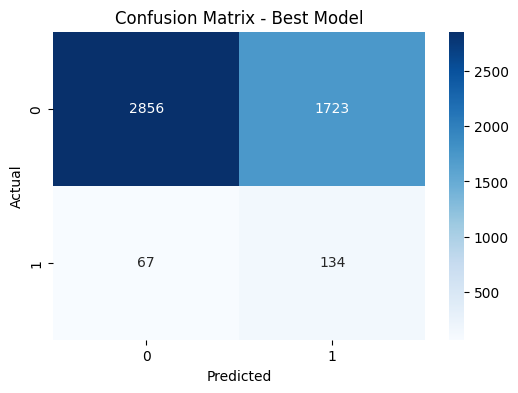

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.62      0.76      4579
           1       0.07      0.67      0.13       201

    accuracy                           0.63      4780
   macro avg       0.52      0.65      0.45      4780
weighted avg       0.94      0.63      0.73      4780



In [30]:
best_pred = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report:")
print(classification_report(y_test, best_pred, zero_division=0))

## 29. ROC Curve

The ROC curve shows how well the model separates good and bad customers.

### Simple Explanation

A curve closer to the top-left corner indicates better model performance.

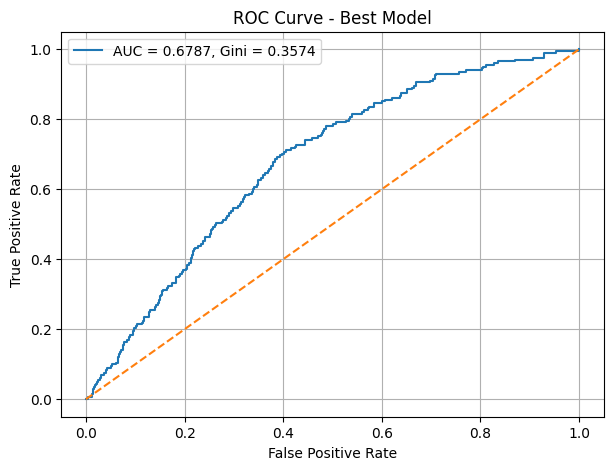

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, best_proba)
auc, gini = calculate_gini(y_test, best_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}, Gini = {gini:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Best Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

## 30. Decile Rank Ordering

Rank ordering is very important in credit risk modeling.

### Simple Explanation

A good model should rank high-risk customers in higher deciles.  
The highest decile should have a higher bad rate than the lowest decile.

,decile,total_customers,bad_customers,avg_probability,bad_rate
9,10,478,39,0.741196,0.081590
8,9,478,33,0.631748,0.069038
7,8,478,33,0.570484,0.069038
6,7,478,33,0.518399,0.069038
5,6,478,19,0.473386,0.039749
4,5,478,13,0.426193,0.027197
3,4,478,12,0.376701,0.025105
2,3,478,7,0.321076,0.014644
1,2,478,6,0.244226,0.012552
0,1,478,6,0.090355,0.012552


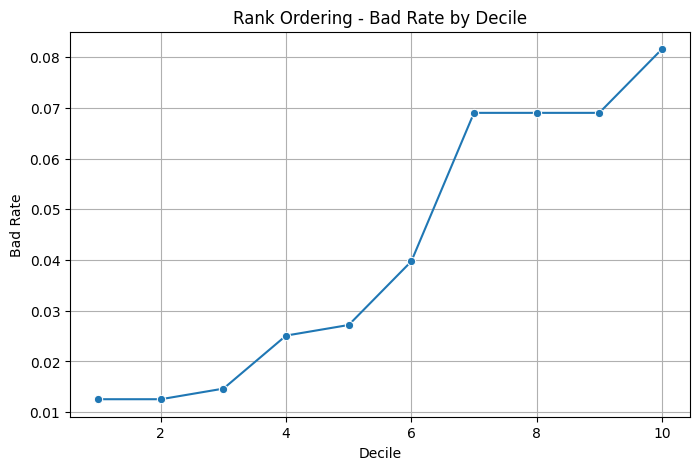

In [32]:
decile_table = create_decile_table(y_test, best_proba)

display(decile_table)

plt.figure(figsize=(8, 5))
sns.lineplot(data=decile_table, x="decile", y="bad_rate", marker="o")
plt.title("Rank Ordering - Bad Rate by Decile")
plt.xlabel("Decile")
plt.ylabel("Bad Rate")
plt.grid(True)
plt.show()

## 31. Feature Importance / Feature Matrix

Feature importance helps explain which variables contributed most to the model.

### Simple Explanation

This supports model explainability and helps business teams understand the key risk drivers.

In [33]:
try:
    fitted_preprocessor = best_model.named_steps["preprocessor"]
    fitted_model = best_model.named_steps["model"]

    feature_names = []
    feature_names.extend(numeric_features)

    if len(categorical_features) > 0:
        encoded_features = (
            fitted_preprocessor
            .named_transformers_["cat"]
            .named_steps["encoder"]
            .get_feature_names_out(categorical_features)
        )
        feature_names.extend(encoded_features)

    if hasattr(fitted_model, "feature_importances_"):
        importances = fitted_model.feature_importances_

        feature_importance = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        }).sort_values(by="Importance", ascending=False)

        display(feature_importance.head(25))

        plt.figure(figsize=(10, 7))
        sns.barplot(data=feature_importance.head(20), x="Importance", y="Feature")
        plt.title("Top 20 Important Features")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.show()
    else:
        print("Selected model does not provide direct feature importance.")
        print("For production, SHAP or permutation importance can be used.")
except Exception as e:
    print("Feature importance could not be extracted.")
    print(e)

Selected model does not provide direct feature importance.
For production, SHAP or permutation importance can be used.


## 32. Business Interpretation

The final model produces a probability score for each customer.

### Practical Use

Bank GoodCredit can use this score to:

1. Identify high-risk customers.
2. Prioritize manual review.
3. Assign risk-based credit limits.
4. Monitor customers likely to become delinquent.
5. Reduce future credit losses.

### Simple Explanation

A higher predicted probability means the customer is more likely to become a bad credit customer.

## 33. Challenges Faced and Techniques Used

### Challenge 1: Multiple SQL Tables

The data was stored in three separate SQL tables.

**Technique Used:**  
Customer-level aggregation was performed and the tables were merged using `customer_no`.

### Challenge 2: Numeric Columns Stored as Text

Many financial columns were stored as object/text.

**Technique Used:**  
Numeric conversion was performed using `pd.to_numeric()` after cleaning blanks and commas.

### Challenge 3: Missing Values After Merge

Some customers did not have account or enquiry records.

**Technique Used:**  
Count features were filled with zero, while other missing values were handled by pipeline-based imputation.

### Challenge 4: Imbalanced Target

Only a small percentage of customers were bad customers.

**Technique Used:**  
Stratified train-test split, class weights, ROC-AUC, Gini, recall, and decile rank ordering were used.

### Challenge 5: High-Cardinality Variables

Some categorical variables appeared to be customer-specific identifiers.

**Technique Used:**  
High-cardinality categorical columns were removed to reduce overfitting and improve production stability.

### Challenge 6: Model Explainability

Banking risk models need explanation.

**Technique Used:**  
Feature importance and rank ordering were included to support business interpretation.

## 34. Final Conclusion

This project built a credit risk prediction model for Bank GoodCredit.

The model predicts whether a customer is likely to become a bad credit customer, defined as 30+ days-past-due risk.  
The project used customer demographics, account history, and enquiry behavior to create a customer-level feature matrix.

Multiple models were compared, including Logistic Regression, Random Forest, and Gradient Boosting.  
Hyperparameter tuning was performed, and the final model was selected using ROC-AUC and Gini.

The model also includes decile rank ordering to validate whether high-risk customers are correctly ranked at the top.

Overall, the project demonstrates how machine learning can support credit risk decision-making, reduce default risk, and improve banking portfolio monitoring.

## 34A. Enhanced Business-Focused Conclusion

This project developed a machine learning-based credit risk prediction model for Bank GoodCredit using customer demographics, account history, and enquiry behavior.

The model was evaluated using ROC-AUC, Gini, classification metrics, and decile rank ordering.  
This is important because credit risk models must not only predict accurately but also rank customers according to risk.

From a business perspective, the model can help the bank identify customers with higher probability of becoming 30+ DPD.  
This enables early intervention, better credit limit decisions, targeted monitoring, and improved risk control.

The final model should be used as a decision-support tool rather than a fully automated approval/rejection system.  
Business rules, regulatory requirements, and manual credit review should still be used along with the model score.

Overall, the project demonstrates how machine learning can support credit risk teams in reducing potential default exposure and improving portfolio quality.

## 35. Future Improvements

The model can be improved further by:

1. Adding recent transaction-level data.
2. Creating more detailed payment delinquency features.
3. Testing XGBoost or LightGBM models.
4. Using SHAP values for deeper explainability.
5. Monitoring model drift over time.
6. Deploying the model as a scoring API.
7. Updating the model periodically with new customer behavior.